# 13. Stage 1 Rule Baseline Evaluation

## 0. 실험 목적 및 원칙

이 노트북은 `11_rule_based_query_retrieval_baseline.ipynb`에서 이미 만들어진 Rule Parser가 실제 사용자 자연어 200개로 구성된 Stage 1 Golden Set을 얼마나 정확하게 구조화하는지 측정한다.

**Exact Match**는 한 Query의 모든 정답 필드가 완전히 맞아야 성공으로 보는 가장 엄격한 평가다. **F1 Score**는 찾아야 할 값을 얼마나 놓치지 않았는지와 잘못 찾은 값이 얼마나 적은지를 함께 보는 점수다.

실험 원칙은 다음과 같다.

- 기존 Rule Parser와 그 Lexicon을 수정하거나 확장하지 않는다.
- Golden Set의 정답을 보고 규칙, 동의어, 매핑을 추가하지 않는다.
- LLM, embedding, 외부 API, 향수 ranking을 사용하지 않는다.
- Parser 입력은 `query_id`, `query_text`뿐이며, 예측 생성과 Gold 비교를 코드 수준에서 분리한다.
- Golden Set과 기존 11번 산출물을 덮어쓰지 않는다.

따라서 결과가 낮더라도 그대로 기록한다. 이 값은 이후 확장 Rule Parser와 LLM Parser를 같은 Golden Set에서 비교하기 위한 최초 기준선이다.

## 1. Environment & Imports

In [1]:
import collections
import json
import pathlib
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

## 2. Path Configuration

In [2]:
PROJECT_ROOT = pathlib.Path.cwd().resolve()
GOLDSET_PATH = PROJECT_ROOT / "evaluation_data" / "stage1" / "13_stage1_golden_set_v1_200.xlsx"
OUTPUT_DIR = PROJECT_ROOT / "analysis_outputs"
LEXICON_PATH = OUTPUT_DIR / "11_rule_lexicon.csv"

required_paths = {
    "Golden Set": GOLDSET_PATH,
    "11번 Rule Lexicon": LEXICON_PATH,
}
for label, path in required_paths.items():
    if not path.is_file():
        raise FileNotFoundError(f"필수 파일이 없습니다 - {label}: {path}")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"GOLDSET_PATH: {GOLDSET_PATH}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

PROJECT_ROOT: C:\Users\SSAFY\Desktop\archive
GOLDSET_PATH: C:\Users\SSAFY\Desktop\archive\evaluation_data\stage1\13_stage1_golden_set_v1_200.xlsx
OUTPUT_DIR: C:\Users\SSAFY\Desktop\archive\analysis_outputs


## 3. Load Golden Set

Excel의 상단 4개 행은 문서 제목과 설명이므로 실제 헤더가 있는 다섯 번째 행(`header=4`)부터 읽는다. JSON 문자열은 모두 `json.loads()`로 Python 객체로 변환한다. 검증 실패 시 평가를 시작하지 않고 즉시 오류를 발생시킨다.

In [3]:
JSON_COLUMNS = [
    "gold_scent_preference",
    "gold_context",
    "gold_performance",
    "gold_avoid",
    "gold_additional_requirements",
]
EXPECTED_COLUMNS = ["query_id", "query_text", *JSON_COLUMNS]


def load_goldset(path=GOLDSET_PATH):
    return pd.read_excel(
        path,
        sheet_name="Golden Set",
        header=4,
        dtype=str,
        keep_default_na=False,
    )


def parse_json_cell(value, query_id, column):
    try:
        return json.loads(value)
    except (TypeError, json.JSONDecodeError) as exc:
        raise ValueError(f"JSON parsing 실패: query_id={query_id}, column={column}") from exc


def validate_goldset(frame):
    if frame.columns.tolist() != EXPECTED_COLUMNS:
        raise ValueError(f"Golden Set 컬럼 불일치: {frame.columns.tolist()}")
    if len(frame) != 200:
        raise ValueError(f"Golden Set은 200개여야 합니다: {len(frame)}")
    if frame["query_id"].eq("").any() or frame["query_text"].eq("").any():
        raise ValueError("query_id 또는 query_text에 빈 값이 있습니다.")
    if frame["query_id"].duplicated().any():
        raise ValueError("중복 query_id가 있습니다.")
    if frame["query_text"].duplicated().any():
        raise ValueError("중복 query_text가 있습니다.")

    parsed = frame.copy()
    for column in JSON_COLUMNS:
        parsed[column] = [
            parse_json_cell(value, query_id, column)
            for value, query_id in zip(frame[column], frame["query_id"])
        ]

    for row in parsed.itertuples(index=False):
        if not isinstance(row.gold_scent_preference, list):
            raise TypeError(f"{row.query_id}: gold_scent_preference는 list여야 합니다.")
        if set(row.gold_context) != {"season", "daypart", "gender"}:
            raise ValueError(f"{row.query_id}: gold_context key 불일치")
        if not all(isinstance(row.gold_context[key], list) for key in row.gold_context):
            raise TypeError(f"{row.query_id}: gold_context 값은 list여야 합니다.")
        if set(row.gold_performance) != {"intensity", "longevity"}:
            raise ValueError(f"{row.query_id}: gold_performance key 불일치")
        if not all(isinstance(row.gold_performance[key], str) for key in row.gold_performance):
            raise TypeError(f"{row.query_id}: gold_performance 값은 str이어야 합니다.")
        if not isinstance(row.gold_avoid, list) or not isinstance(row.gold_additional_requirements, list):
            raise TypeError(f"{row.query_id}: avoid/additional은 list여야 합니다.")
    return parsed


gold_raw_df = load_goldset()
gold_df = validate_goldset(gold_raw_df)

gold_presence = pd.Series({
    "scent_preference": int(gold_df["gold_scent_preference"].map(bool).sum()),
    "context": int(gold_df["gold_context"].map(lambda x: any(map(bool, x.values()))).sum()),
    "performance": int(gold_df["gold_performance"].map(lambda x: any(map(bool, x.values()))).sum()),
    "avoid": int(gold_df["gold_avoid"].map(bool).sum()),
    "additional_requirements": int(gold_df["gold_additional_requirements"].map(bool).sum()),
}, name="gold_nonempty_query_count")

print(f"Golden Set Query count: {len(gold_df)}")
print(f"Unique query_id count: {gold_df['query_id'].nunique()}")
print(f"Unique query_text count: {gold_df['query_text'].nunique()}")
display(gold_presence.to_frame())

Golden Set Query count: 200
Unique query_id count: 200
Unique query_text count: 200


,gold_nonempty_query_count
scent_preference,39
context,43
performance,17
avoid,36
additional_requirements,170


## 4. Load / Reconstruct Existing Rule Parser

아래 코드는 11번 노트북의 기존 Parser 핵심 로직을 평가용으로 가져온 것이다. 11번이 이미 고정해 저장한 `11_rule_lexicon.csv` 2,638개 규칙을 그대로 읽으며, 이 노트북에서는 규칙이나 Lexicon을 추가하지 않는다. Parser 함수는 Gold 데이터프레임을 인자로 받지 않는다.

In [4]:
def normalize_text(text):
    text = unicodedata.normalize("NFKC", str(text)).casefold()
    return re.sub(r"\s+", " ", text).strip()


rule_lexicon_df = pd.read_csv(LEXICON_PATH, dtype=str, keep_default_na=False)
expected_lexicon_columns = {
    "surface_form", "normalized_form", "feature_type",
    "feature_name", "mapping_type", "evidence_level",
}
if set(rule_lexicon_df.columns) != expected_lexicon_columns:
    raise ValueError("11번 Rule Lexicon 스키마가 예상과 다릅니다.")

rules_by_surface = collections.defaultdict(list)
for row in rule_lexicon_df.to_dict("records"):
    rules_by_surface[row["normalized_form"]].append(row)
sorted_surfaces = sorted(rules_by_surface, key=lambda value: (-len(value), value))

# 11번 Parser에 포함된 unresolved 표현 범주를 그대로 재구성한다.
unresolved_patterns = [
    (r"비\s*오는\s*날", "비 오는 날"),
    (r"오래된\s*호텔\s*로비", "오래된 호텔 로비"),
    (r"고급스러운\s*이불", "고급스러운 이불"),
    (r"호텔\s*로비", "호텔 로비"),
    (r"깨끗(?:한|하고|하게)?", "깨끗한"),
    (r"청초(?:한|하고|하게)?", "청초한"),
    (r"차분(?:한|하고|하게)?", "차분한"),
    (r"깔끔(?:한|하고|하게)?", "깔끔한"),
    (r"고급스러(?:운|워|운)?", "고급스러운"),
    (r"휴양지", "휴양지"),
    (r"호텔", "호텔"),
    (r"이불", "이불"),
]


def spans_overlap(span, occupied):
    start, end = span
    return any(start < used_end and used_start < end for used_start, used_end in occupied)


def surface_matches(normalized_query, surface):
    escaped = re.escape(surface)
    if re.search(r"[a-z0-9]", surface):
        pattern = rf"(?<![a-z0-9]){escaped}(?![a-z0-9])"
    else:
        pattern = escaped
    return list(re.finditer(pattern, normalized_query))


def choose_rule(candidates, original_fragment, after_text):
    by_type = collections.defaultdict(list)
    for candidate in candidates:
        by_type[candidate["feature_type"]].append(candidate)
    if "NOTE" in by_type and re.search(r"^\s*(노트|note)", after_text):
        return by_type["NOTE"][0]
    if "ACCORD" in by_type and re.search(r"^\s*(향|accord)", after_text):
        return by_type["ACCORD"][0]
    if "SEASON" in by_type:
        return by_type["SEASON"][0]
    if "DAYPART" in by_type:
        return by_type["DAYPART"][0]
    if len(by_type) == 1:
        return candidates[0]
    if "NOTE" in by_type and any(character.isupper() for character in original_fragment):
        return by_type["NOTE"][0]
    if "ACCORD" in by_type:
        return by_type["ACCORD"][0]
    return candidates[0]


def parse_with_existing_rules(query):
    normalized_query = normalize_text(query)
    occupied = []
    resolved_matches = []
    for surface in sorted_surfaces:
        for match in surface_matches(normalized_query, surface):
            if spans_overlap(match.span(), occupied):
                continue
            original_fragment = str(query)[match.start():match.end()]
            after_text = normalized_query[match.end():match.end() + 12]
            chosen = choose_rule(rules_by_surface[surface], original_fragment, after_text)
            resolved_matches.append((match.start(), chosen))
            occupied.append(match.span())

    unresolved_matches = []
    for pattern, label in unresolved_patterns:
        for match in re.finditer(pattern, normalized_query):
            if spans_overlap(match.span(), occupied):
                continue
            unresolved_matches.append((match.start(), label))
            occupied.append(match.span())

    result = {"accords": [], "notes": [], "seasons": [], "dayparts": [], "unresolved": []}
    target_key = {"ACCORD": "accords", "NOTE": "notes", "SEASON": "seasons", "DAYPART": "dayparts"}
    for _, chosen in sorted(resolved_matches, key=lambda item: item[0]):
        key = target_key[chosen["feature_type"]]
        value = chosen["feature_name"]
        if value not in result[key]:
            result[key].append(value)
    for _, label in sorted(unresolved_matches, key=lambda item: item[0]):
        if label not in result["unresolved"]:
            result["unresolved"].append(label)
    return result


print(f"고정된 Rule Lexicon 행 수: {len(rule_lexicon_df):,}")
display(rule_lexicon_df.groupby(["feature_type", "mapping_type"]).size().to_frame("rule_count"))

고정된 Rule Lexicon 행 수: 2,638


rule_count
feature_type mapping_type                      
ACCORD       KOREAN_TRANSLITERATION          10
             LEVEL_A_DIRECT                  92
DAYPART      ENGLISH_CONTEXT_ALIAS            2
             LEVEL_A_DIRECT                   2
NOTE         LEVEL_A_DIRECT                2523
SEASON       ENGLISH_CONTEXT_ALIAS            5
             LEVEL_A_DIRECT                   4

## 5. Stage 1 Adapter

Adapter는 기존 Parser의 출력 형식을 Golden Schema와 비교 가능한 구조로 옮길 뿐, 새로운 자연어 해석 기능을 추가하지 않는다.

- `accords + notes` → `scent_preference`
- `seasons` → `context.season`
- `dayparts` → `context.daypart`
- 기존 Parser가 지원하지 않는 gender, performance, avoid, additional 필드는 빈 기본값

In [5]:
def deduplicate_preserving_order(values):
    seen = set()
    result = []
    for value in values:
        if value not in seen:
            seen.add(value)
            result.append(value)
    return result


def adapt_to_stage1_schema(parsed):
    return {
        "scent_preference": deduplicate_preserving_order(parsed["accords"] + parsed["notes"]),
        "context": {
            "season": list(parsed["seasons"]),
            "daypart": list(parsed["dayparts"]),
            "gender": [],
        },
        "performance": {"intensity": "", "longevity": ""},
        "avoid": [],
        "additional_requirements": [],
    }


display(pd.DataFrame([
    {"existing_parser_field": "accords + notes", "stage1_field": "scent_preference"},
    {"existing_parser_field": "seasons", "stage1_field": "context.season"},
    {"existing_parser_field": "dayparts", "stage1_field": "context.daypart"},
    {"existing_parser_field": "지원하지 않음", "stage1_field": "gender / performance / avoid / additional"},
]))

,existing_parser_field,stage1_field
0,accords + notes,scent_preference
1,seasons,context.season
2,dayparts,context.daypart
3,지원하지 않음,gender / performance / avoid / additional


## 6. Run Rule Parser on 200 Queries

아래 `queries_df`에는 정답 열이 없다. Query별 오류는 기본 예측과 함께 별도로 기록하여 한 건의 오류가 전체 200건 실행을 중단하지 않게 한다.

In [6]:
def run_rule_parser(queries):
    prediction_rows = []
    parser_error_rows = []
    empty_prediction = adapt_to_stage1_schema({
        "accords": [], "notes": [], "seasons": [], "dayparts": [], "unresolved": []
    })
    for row in queries.itertuples(index=False):
        try:
            parsed = parse_with_existing_rules(row.query_text)
            prediction = adapt_to_stage1_schema(parsed)
            parser_error = ""
        except Exception as exc:
            prediction = empty_prediction
            parser_error = f"{type(exc).__name__}: {exc}"
            parser_error_rows.append({
                "query_id": row.query_id,
                "query_text": row.query_text,
                "parser_error": parser_error,
            })
        prediction_rows.append({
            "query_id": row.query_id,
            "query_text": row.query_text,
            "pred_scent_preference": prediction["scent_preference"],
            "pred_context": prediction["context"],
            "pred_performance": prediction["performance"],
            "pred_avoid": prediction["avoid"],
            "pred_additional_requirements": prediction["additional_requirements"],
            "parser_error": parser_error,
        })
    return pd.DataFrame(prediction_rows), pd.DataFrame(
        parser_error_rows, columns=["query_id", "query_text", "parser_error"]
    )


queries_df = gold_df[["query_id", "query_text"]].copy()
predictions_df, parser_errors_df = run_rule_parser(queries_df)

if len(predictions_df) != 200 or predictions_df["query_id"].nunique() != 200:
    raise RuntimeError("200개 Query 예측이 완전하게 생성되지 않았습니다.")

print(f"처리된 Query: {len(predictions_df)}")
print(f"Parser 오류: {len(parser_errors_df)}")
display(predictions_df.head(10))
if len(parser_errors_df):
    display(parser_errors_df)

처리된 Query: 200
Parser 오류: 0


,query_id,query_text,pred_scent_preference,pred_context,pred_performance,pred_avoid,pred_additional_requirements,parser_error
0,UQ0001,비가 온 뒤의 숲같은 향을 찾고 있어,[],"{'season': [], 'daypart': [], 'gender': []}","{'intensity': '', 'longevity': ''}",[],[],
1,UQ0002,시트러스 계열의 깔끔한 향의 향수가 있어?,[citrus],"{'season': [], 'daypart': [], 'gender': []}","{'intensity': '', 'longevity': ''}",[],[],
2,UQ0003,향수 가격 적당한 거 추천해줘. 그냥 구색 갖추려고 사는 거야.,[],"{'season': [], 'daypart': [], 'gender': []}","{'intensity': '', 'longevity': ''}",[],[],
3,UQ0004,"여성스러운 향을 사고 싶은데, 너무 달콤한 건 싫어. 그런 향기가 있을까?",[],"{'season': [], 'daypart': [], 'gender': []}","{'intensity': '', 'longevity': ''}",[],[],
4,UQ0005,난 바닐라 향기가 좋은데. 너무 단 건 싫어.,[vanilla],"{'season': [], 'daypart': [], 'gender': []}","{'intensity': '', 'longevity': ''}",[],[],
5,UQ0006,바다 냄새 나는 향수가 있나? 가능함?,[],"{'season': [], 'daypart': [], 'gender': []}","{'intensity': '', 'longevity': ''}",[],[],
6,UQ0007,30대 초반 남자가 쓰기 좋은 향수 추천해줘,[],"{'season': [], 'daypart': [], 'gender': []}","{'intensity': '', 'longevity': ''}",[],[],
7,UQ0008,레몬 말고. 레몬 껍질 냄새나는 향수 있음?,[],"{'season': [], 'daypart': [], 'gender': []}","{'intensity': '', 'longevity': ''}",[],[],
8,UQ0009,"중성적인 향수 뿌리고 싶어. 너무 여성스럽지 않되, 너무 남자 향수도 아니었으면 좋겠다.",[],"{'season': [], 'daypart': [], 'gender': []}","{'intensity': '', 'longevity': ''}",[],[],
9,UQ0010,"케이크 같으면서도, 너무 느끼하지 않고, 딱 맡았을 때 공주처럼 느껴지는 향수 그런 거 없음?",[],"{'season': [], 'daypart': [], 'gender': []}","{'intensity': '', 'longevity': ''}",[],[],


## 7. Normalize Gold and Prediction

Normalization은 표현 형식 차이만 정리한다. 앞뒤 공백 제거, 대소문자 무시, 배열 순서 무시, 중복 제거만 허용한다. 동의어 사전, 의미 유사도, embedding, 수동 정답 매핑은 사용하지 않는다.

In [7]:
def normalize_scalar(value):
    return normalize_text(value)


def normalize_list(values):
    return frozenset(normalize_scalar(value) for value in values if normalize_scalar(value))


def normalize_context(value):
    return {
        "season": normalize_list(value["season"]),
        "daypart": normalize_list(value["daypart"]),
        "gender": normalize_list(value["gender"]),
    }


def normalize_performance(value):
    return {
        "intensity": normalize_scalar(value["intensity"]),
        "longevity": normalize_scalar(value["longevity"]),
    }


def json_text(value):
    return json.dumps(value, ensure_ascii=False, separators=(",", ":"))

## 8. Evaluation Metrics

In [8]:
def safe_divide(numerator, denominator):
    return numerator / denominator if denominator else 0.0


def evaluate_multilabel(gold_values, pred_values, mask=None):
    if mask is None:
        mask = np.ones(len(gold_values), dtype=bool)
    tp = fp = fn = 0
    eligible = 0
    for gold, pred, include in zip(gold_values, pred_values, mask):
        if not include:
            continue
        eligible += 1
        gold_set = normalize_list(gold)
        pred_set = normalize_list(pred)
        tp += len(gold_set & pred_set)
        fp += len(pred_set - gold_set)
        fn += len(gold_set - pred_set)
    precision = safe_divide(tp, tp + fp)
    recall = safe_divide(tp, tp + fn)
    f1 = safe_divide(2 * precision * recall, precision + recall)
    return {
        "precision": precision, "recall": recall, "f1": f1,
        "tp": tp, "fp": fp, "fn": fn, "eligible_queries": eligible,
    }


def scalar_accuracy(gold_values, pred_values, mask=None):
    if mask is None:
        mask = np.ones(len(gold_values), dtype=bool)
    compared = [
        normalize_scalar(gold) == normalize_scalar(pred)
        for gold, pred, include in zip(gold_values, pred_values, mask)
        if include
    ]
    return {"accuracy": float(np.mean(compared)) if compared else np.nan,
            "eligible_queries": len(compared)}


def list_exact(gold, pred):
    return normalize_list(gold) == normalize_list(pred)


def context_exact(gold, pred):
    return normalize_context(gold) == normalize_context(pred)


def performance_exact(gold, pred):
    return normalize_performance(gold) == normalize_performance(pred)

## 9. Field-level Evaluation

In [9]:
merged_df = gold_df.merge(predictions_df, on=["query_id", "query_text"], how="left", validate="one_to_one")
if merged_df["pred_scent_preference"].isna().any():
    raise RuntimeError("예측 누락 Query가 있습니다.")

evaluation_rows = []
for row in merged_df.itertuples(index=False):
    matches = {
        "scent": list_exact(row.gold_scent_preference, row.pred_scent_preference),
        "context": context_exact(row.gold_context, row.pred_context),
        "performance": performance_exact(row.gold_performance, row.pred_performance),
        "avoid": list_exact(row.gold_avoid, row.pred_avoid),
        "additional": list_exact(row.gold_additional_requirements, row.pred_additional_requirements),
    }
    evaluation_rows.append({
        "query_id": row.query_id,
        "query_text": row.query_text,
        "gold_scent": json_text(row.gold_scent_preference),
        "pred_scent": json_text(row.pred_scent_preference),
        "scent_match": matches["scent"],
        "gold_context": json_text(row.gold_context),
        "pred_context": json_text(row.pred_context),
        "context_match": matches["context"],
        "gold_performance": json_text(row.gold_performance),
        "pred_performance": json_text(row.pred_performance),
        "performance_match": matches["performance"],
        "gold_avoid": json_text(row.gold_avoid),
        "pred_avoid": json_text(row.pred_avoid),
        "avoid_match": matches["avoid"],
        "gold_additional": json_text(row.gold_additional_requirements),
        "pred_additional": json_text(row.pred_additional_requirements),
        "additional_match": matches["additional"],
        "overall_exact_match": all(matches.values()),
        "parser_error": row.parser_error,
    })

evaluation_df = pd.DataFrame(evaluation_rows)

field_exact_rates = pd.Series({
    "scent": evaluation_df["scent_match"].mean(),
    "context": evaluation_df["context_match"].mean(),
    "performance": evaluation_df["performance_match"].mean(),
    "avoid": evaluation_df["avoid_match"].mean(),
    "additional": evaluation_df["additional_match"].mean(),
}, name="exact_match_rate")

subfield_exact_rates = pd.Series({
    "context.season": np.mean([list_exact(g["season"], p["season"]) for g, p in zip(merged_df.gold_context, merged_df.pred_context)]),
    "context.daypart": np.mean([list_exact(g["daypart"], p["daypart"]) for g, p in zip(merged_df.gold_context, merged_df.pred_context)]),
    "context.gender": np.mean([list_exact(g["gender"], p["gender"]) for g, p in zip(merged_df.gold_context, merged_df.pred_context)]),
    "performance.intensity": np.mean([normalize_scalar(g["intensity"]) == normalize_scalar(p["intensity"]) for g, p in zip(merged_df.gold_performance, merged_df.pred_performance)]),
    "performance.longevity": np.mean([normalize_scalar(g["longevity"]) == normalize_scalar(p["longevity"]) for g, p in zip(merged_df.gold_performance, merged_df.pred_performance)]),
}, name="exact_match_rate")

exact_match_count = int(evaluation_df["overall_exact_match"].sum())
exact_match_rate = float(evaluation_df["overall_exact_match"].mean())
print(f"전체 Query Exact Match: {exact_match_count}/200 ({exact_match_rate:.2%})")
display(field_exact_rates.to_frame())
display(subfield_exact_rates.to_frame())

전체 Query Exact Match: 3/200 (1.50%)


,exact_match_rate
scent,0.8400
context,0.8050
performance,0.9150
avoid,0.8200
additional,0.1500


,exact_match_rate
context.season,0.9900
context.daypart,0.9900
context.gender,0.8200
performance.intensity,0.9400
performance.longevity,0.9700


## 10. Positive-only Evaluation

정답과 예측이 모두 비어 있는 Query가 많으면 전체 점수가 실제 추출 능력보다 높아 보일 수 있다. **Positive-only Evaluation**은 해당 Feature가 Gold에 실제로 존재하는 Query만 골라 계산한 성능이다. 배열 필드는 Micro Precision/Recall/F1, 단일 문자열 필드는 Accuracy를 사용한다.

In [10]:
multilabel_fields = {
    "scent": (merged_df.gold_scent_preference.tolist(), merged_df.pred_scent_preference.tolist()),
    "season": ([x["season"] for x in merged_df.gold_context], [x["season"] for x in merged_df.pred_context]),
    "daypart": ([x["daypart"] for x in merged_df.gold_context], [x["daypart"] for x in merged_df.pred_context]),
    "gender": ([x["gender"] for x in merged_df.gold_context], [x["gender"] for x in merged_df.pred_context]),
    "avoid": (merged_df.gold_avoid.tolist(), merged_df.pred_avoid.tolist()),
    "additional": (merged_df.gold_additional_requirements.tolist(), merged_df.pred_additional_requirements.tolist()),
}

all_multilabel_metrics = {}
positive_multilabel_metrics = {}
for field, (gold_values, pred_values) in multilabel_fields.items():
    all_multilabel_metrics[field] = evaluate_multilabel(gold_values, pred_values)
    positive_mask = np.asarray([bool(normalize_list(value)) for value in gold_values])
    positive_multilabel_metrics[field] = evaluate_multilabel(gold_values, pred_values, positive_mask)

intensity_gold = [x["intensity"] for x in merged_df.gold_performance]
intensity_pred = [x["intensity"] for x in merged_df.pred_performance]
longevity_gold = [x["longevity"] for x in merged_df.gold_performance]
longevity_pred = [x["longevity"] for x in merged_df.pred_performance]

scalar_metrics = {
    "intensity": scalar_accuracy(intensity_gold, intensity_pred),
    "longevity": scalar_accuracy(longevity_gold, longevity_pred),
}
positive_scalar_metrics = {
    "intensity": scalar_accuracy(intensity_gold, intensity_pred, np.asarray([bool(normalize_scalar(x)) for x in intensity_gold])),
    "longevity": scalar_accuracy(longevity_gold, longevity_pred, np.asarray([bool(normalize_scalar(x)) for x in longevity_gold])),
}

positive_rows = []
for field, values in positive_multilabel_metrics.items():
    positive_rows.append({
        "field": field, "metric": "Micro F1", "value": values["f1"],
        "eligible_queries": values["eligible_queries"],
    })
for field, values in positive_scalar_metrics.items():
    positive_rows.append({
        "field": field, "metric": "Accuracy", "value": values["accuracy"],
        "eligible_queries": values["eligible_queries"],
    })
positive_performance_df = pd.DataFrame(positive_rows)
display(positive_performance_df)

,field,metric,value,eligible_queries
0,scent,Micro F1,0.4590,39
1,season,Micro F1,1.0000,10
2,daypart,Micro F1,0.0000,0
3,gender,Micro F1,0.0000,36
4,avoid,Micro F1,0.0000,36
5,additional,Micro F1,0.0000,170
6,intensity,Accuracy,0.0000,12
7,longevity,Accuracy,0.0000,6


## 11. Error Analysis

In [11]:
def component_error_types(row):
    errors = []
    gold_scent = normalize_list(row.gold_scent_preference)
    pred_scent = normalize_list(row.pred_scent_preference)
    if gold_scent != pred_scent:
        if gold_scent and not pred_scent:
            errors.append("MISSED_SCENT")
        elif pred_scent and not gold_scent:
            errors.append("EXTRA_SCENT")
        else:
            errors.append("WRONG_SCENT")

    for field, error_name in [
        ("season", "MISSED_SEASON"),
        ("daypart", "MISSED_DAYPART"),
        ("gender", "MISSED_GENDER"),
    ]:
        gold_value = normalize_list(row.gold_context[field])
        pred_value = normalize_list(row.pred_context[field])
        if gold_value != pred_value:
            errors.append(error_name if gold_value else f"EXTRA_{field.upper()}")

    for field, error_name in [
        ("intensity", "MISSED_INTENSITY"),
        ("longevity", "MISSED_LONGEVITY"),
    ]:
        gold_value = normalize_scalar(row.gold_performance[field])
        pred_value = normalize_scalar(row.pred_performance[field])
        if gold_value != pred_value:
            errors.append(error_name if gold_value else f"EXTRA_{field.upper()}")

    if normalize_list(row.gold_avoid) != normalize_list(row.pred_avoid):
        errors.append("MISSED_AVOID" if normalize_list(row.gold_avoid) else "EXTRA_AVOID")
    if normalize_list(row.gold_additional_requirements) != normalize_list(row.pred_additional_requirements):
        errors.append("MISSED_ADDITIONAL" if normalize_list(row.gold_additional_requirements) else "EXTRA_ADDITIONAL")
    if row.parser_error:
        errors.append("PARSER_ERROR")
    return errors


error_components = [component_error_types(row) for row in merged_df.itertuples(index=False)]
evaluation_df["error_components"] = [json_text(items) for items in error_components]
evaluation_df["error_type"] = [
    "" if not items else items[0] if len(items) == 1 else "MULTIPLE_ERRORS"
    for items in error_components
]

errors_df = evaluation_df.loc[~evaluation_df["overall_exact_match"]].copy()
component_counts = collections.Counter(
    component for components in error_components for component in components
)
error_type_counts = errors_df["error_type"].value_counts()

print(f"Exact Match 실패 Query: {len(errors_df)}")
display(error_type_counts.to_frame("query_count"))
display(pd.Series(component_counts, name="component_count").sort_values(ascending=False).to_frame())

display(Markdown("### 1. 전체 Exact Match 실패 Query 중 앞 20개"))
display(errors_df.head(20)[["query_id", "query_text", "error_type", "error_components"]])

failure_views = [
    ("Gold scent가 있지만 Rule이 찾지 못한 Query", "MISSED_SCENT"),
    ("Gold context가 있지만 Rule이 찾지 못한 Query", None),
    ("Gold performance가 있지만 Rule이 찾지 못한 Query", None),
    ("Gold avoid가 있지만 Rule이 찾지 못한 Query", "MISSED_AVOID"),
    ("Gold additional_requirements가 있지만 Rule이 찾지 못한 Query", "MISSED_ADDITIONAL"),
]

view_masks = [
    ["MISSED_SCENT" in items for items in error_components],
    [any(name in items for name in ["MISSED_SEASON", "MISSED_DAYPART", "MISSED_GENDER"]) for items in error_components],
    [any(name in items for name in ["MISSED_INTENSITY", "MISSED_LONGEVITY"]) for items in error_components],
    ["MISSED_AVOID" in items for items in error_components],
    ["MISSED_ADDITIONAL" in items for items in error_components],
]
for (title, _), mask in zip(failure_views, view_masks):
    display(Markdown(f"### {title}"))
    display(evaluation_df.loc[mask].head(20)[[
        "query_id", "query_text", "gold_scent", "pred_scent",
        "gold_context", "pred_context", "gold_performance", "pred_performance",
        "gold_avoid", "pred_avoid", "gold_additional", "pred_additional",
    ]])

Exact Match 실패 Query: 197


,query_count
error_type,
MISSED_ADDITIONAL,97
MULTIPLE_ERRORS,83
MISSED_SCENT,7
MISSED_AVOID,6
MISSED_GENDER,3
MISSED_LONGEVITY,1


,component_count
MISSED_ADDITIONAL,170
MISSED_GENDER,36
MISSED_AVOID,36
MISSED_SCENT,25
MISSED_INTENSITY,12
MISSED_LONGEVITY,6
EXTRA_SCENT,4
WRONG_SCENT,3
EXTRA_SEASON,2
EXTRA_DAYPART,2


### 1. 전체 Exact Match 실패 Query 중 앞 20개

,query_id,query_text,error_type,error_components
0,UQ0001,비가 온 뒤의 숲같은 향을 찾고 있어,MISSED_ADDITIONAL,"[""MISSED_ADDITIONAL""]"
1,UQ0002,시트러스 계열의 깔끔한 향의 향수가 있어?,MISSED_ADDITIONAL,"[""MISSED_ADDITIONAL""]"
2,UQ0003,향수 가격 적당한 거 추천해줘. 그냥 구색 갖추려고 사는 거야.,MISSED_ADDITIONAL,"[""MISSED_ADDITIONAL""]"
3,UQ0004,"여성스러운 향을 사고 싶은데, 너무 달콤한 건 싫어. 그런 향기가 있을까?",MULTIPLE_ERRORS,"[""MISSED_GENDER"",""MISSED_AVOID""]"
4,UQ0005,난 바닐라 향기가 좋은데. 너무 단 건 싫어.,MISSED_AVOID,"[""MISSED_AVOID""]"
5,UQ0006,바다 냄새 나는 향수가 있나? 가능함?,MISSED_SCENT,"[""MISSED_SCENT""]"
6,UQ0007,30대 초반 남자가 쓰기 좋은 향수 추천해줘,MULTIPLE_ERRORS,"[""MISSED_GENDER"",""MISSED_ADDITIONAL""]"
7,UQ0008,레몬 말고. 레몬 껍질 냄새나는 향수 있음?,MISSED_SCENT,"[""MISSED_SCENT""]"
8,UQ0009,"중성적인 향수 뿌리고 싶어. 너무 여성스럽지 않되, 너무 남자 향수도 아니었으면 좋겠다.",MISSED_GENDER,"[""MISSED_GENDER""]"
9,UQ0010,"케이크 같으면서도, 너무 느끼하지 않고, 딱 맡았을 때 공주처럼 느껴지는 향수 그런 거 없음?",MULTIPLE_ERRORS,"[""MISSED_SCENT"",""MISSED_AVOID"",""MISSED_ADDITIONAL""]"


...

,query_id,query_text,gold_scent,pred_scent,gold_context,pred_context,gold_performance,pred_performance,gold_avoid,pred_avoid,gold_additional,pred_additional
29,UQ0030,사람 많은 곳에서도 너무 강하게 느껴지지 않는 은은한 향수를 추천해줘.,[],[],"{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":""LOW"",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}","[""강하게""]",[],"[""사람 많은 곳"",""은은한""]",[]
33,UQ0034,너무 향수 뿌린 티 안나는 걸로 추천해줘,[],[],"{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":""LOW"",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}",[],[],"[""향수 뿌린 티 안나는""]",[]
47,UQ0048,비누향이나 섬유유연제 향이 강하게 나는 향수 추천해줘,"[""Soap""]",[],"{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":""HIGH"",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}",[],[],"[""섬유유연제 향""]",[]
55,UQ0056,아로마 계열이면 다 좋은데 너무 진한 향 아니고 은은한 게 좋아,"[""aromatic""]",[],"{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":""LOW"",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}","[""너무 진한 향""]",[],"[""아로마 계열""]",[]
64,UQ0065,은은하게 잔향 좋은 거. 향은 딱히 선호 없음 모름 잘,[],[],"{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":""LOW"",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}",[],[],"[""잔향 좋은 거"",""선호 없음""]",[]
65,UQ0066,자연스러운 향수 갖고싶음 은은한 살냄새 같은 걸로,[],[],"{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":""LOW"",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}",[],[],"[""자연스러운"",""은은한 살냄새""]",[]
90,UQ0091,회사에서 쓰기 좋은 은은한 향수 추천해줘,[],[],"{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":""LOW"",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}",[],[],"[""회사"",""은은한""]",[]
91,UQ0092,향이 너무 세지 않은 향수 추천해줘,[],[],"{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":""LOW"",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}","[""향이 너무 세""]",[],[],[]
105,UQ0106,지속력 좋은 남자 향수 추천해줘,[],[],"{""season"":[],""daypart"":[],""gender"":[""male""]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":"""",""longevity"":""HIGH""}","{""intensity"":"""",""longevity"":""""}",[],[],[],[]
116,UQ0117,시트러스 향이 오래가는 향수 추천해줘,"[""Citrus""]","[""citrus""]","{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":"""",""longevity"":""HIGH""}","{""intensity"":"""",""longevity"":""""}",[],[],[],[]


### Gold avoid가 있지만 Rule이 찾지 못한 Query

,query_id,query_text,gold_scent,pred_scent,gold_context,pred_context,gold_performance,pred_performance,gold_avoid,pred_avoid,gold_additional,pred_additional
3,UQ0004,"여성스러운 향을 사고 싶은데, 너무 달콤한 건 싫어. 그런 향기가 있을까?",[],[],"{""season"":[],""daypart"":[],""gender"":[""female""]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":"""",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}","[""달콤한""]",[],[],[]
4,UQ0005,난 바닐라 향기가 좋은데. 너무 단 건 싫어.,"[""Vanilla""]","[""vanilla""]","{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":"""",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}","[""너무 단""]",[],[],[]
9,UQ0010,"케이크 같으면서도, 너무 느끼하지 않고, 딱 맡았을 때 공주처럼 느껴지는 향수 그런 거 없음?","[""Cake""]",[],"{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":"""",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}","[""너무 느끼""]",[],"[""공주""]",[]
10,UQ0011,나무 냄새 나는데 너무 절 냄새만 나면 안됨,"[""Trees""]",[],"{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":"""",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}","[""절 냄새""]",[],[],[]
15,UQ0016,여름에 뿌릴 향수 가지고 싶은데 향기 너무 많이 나면 코 아파서... 안 그런거 추천 가능한가?,[],[],"{""season"":[""summer""],""daypart"":[],""gender"":[]}","{""season"":[""summer""],""daypart"":[],""gender"":[]}","{""intensity"":"""",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}","[""향기 너무 많이 나면""]",[],[],[]
19,UQ0020,향수 분사 적당히 되는 거 없나? 입자가 너무 작은 건 싫은데.,[],[],"{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":"""",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}","[""입자가 너무 작은 건""]",[],"[""분사 적당히 되는 거""]",[]
21,UQ0022,나 조말론 블랙베리는 별로더라... 이런 나한테 추천해줄 만한 향수 없나,[],[],"{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":"""",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}","[""조말론 블랙베리""]",[],[],[]
24,UQ0025,소개팅할 때 부담스럽지 않으면서 좋은 인상을 줄 수 있는 향수 추천해줘.,[],[],"{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":"""",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}","[""부담""]",[],"[""소개팅"",""좋은 인상""]",[]
29,UQ0030,사람 많은 곳에서도 너무 강하게 느껴지지 않는 은은한 향수를 추천해줘.,[],[],"{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":""LOW"",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}","[""강하게""]",[],"[""사람 많은 곳"",""은은한""]",[]
31,UQ0032,향수 냄새가 강하면 머리가 아파서 최대한 부드럽고 편안한 향을 찾고 있어.,[],[],"{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":"""",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}","[""강하면""]",[],"[""부드럽"",""편안한 향""]",[]


### Gold additional_requirements가 있지만 Rule이 찾지 못한 Query

,query_id,query_text,gold_scent,pred_scent,gold_context,pred_context,gold_performance,pred_performance,gold_avoid,pred_avoid,gold_additional,pred_additional
0,UQ0001,비가 온 뒤의 숲같은 향을 찾고 있어,[],[],"{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":"""",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}",[],[],"[""비가 온 뒤"",""숲""]",[]
1,UQ0002,시트러스 계열의 깔끔한 향의 향수가 있어?,"[""Citrus""]","[""citrus""]","{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":"""",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}",[],[],"[""깔끔한""]",[]
2,UQ0003,향수 가격 적당한 거 추천해줘. 그냥 구색 갖추려고 사는 거야.,[],[],"{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":"""",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}",[],[],"[""가격 적당"",""구색 갖추려고""]",[]
6,UQ0007,30대 초반 남자가 쓰기 좋은 향수 추천해줘,[],[],"{""season"":[],""daypart"":[],""gender"":[""male""]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":"""",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}",[],[],"[""30대 초반""]",[]
9,UQ0010,"케이크 같으면서도, 너무 느끼하지 않고, 딱 맡았을 때 공주처럼 느껴지는 향수 그런 거 없음?","[""Cake""]",[],"{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":"""",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}","[""너무 느끼""]",[],"[""공주""]",[]
11,UQ0012,깨끗한 냄새 없나?,[],[],"{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":"""",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}",[],[],"[""깨끗한 냄새""]",[]
12,UQ0013,코코넛 향기 나는데 머리 너무 안 아팠으면 좋겠음,"[""Coconut""]",[],"{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":"""",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}",[],[],"[""머리 너무 안 아팠으면""]",[]
13,UQ0014,나 향수를 잘 모르는데 혹시 추천해줄 수 있어?,[],[],"{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":"""",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}",[],[],"[""잘 모르는데 혹시 추천""]",[]
16,UQ0017,어른스러운 느낌 나는 향수 가지고 싶다. 나는 34살 금융맨임.,[],[],"{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":"""",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}",[],[],"[""어른스러운 느낌"",""34살"",""금융맨""]",[]
17,UQ0018,여자친구가 생겼는데 여친한테 점수 딸만한 향기 없나...?,[],[],"{""season"":[],""daypart"":[],""gender"":[]}","{""season"":[],""daypart"":[],""gender"":[]}","{""intensity"":"""",""longevity"":""""}","{""intensity"":"""",""longevity"":""""}",[],[],"[""여친한테 점수 딸만한""]",[]


## 12. Visualizations

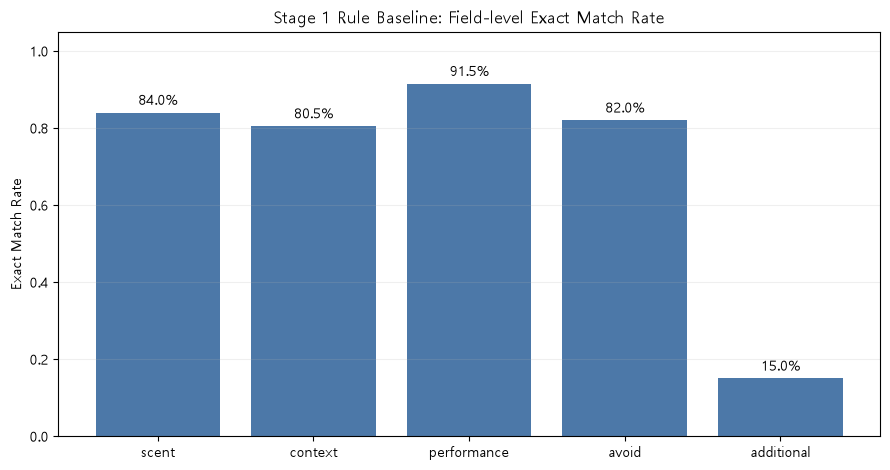

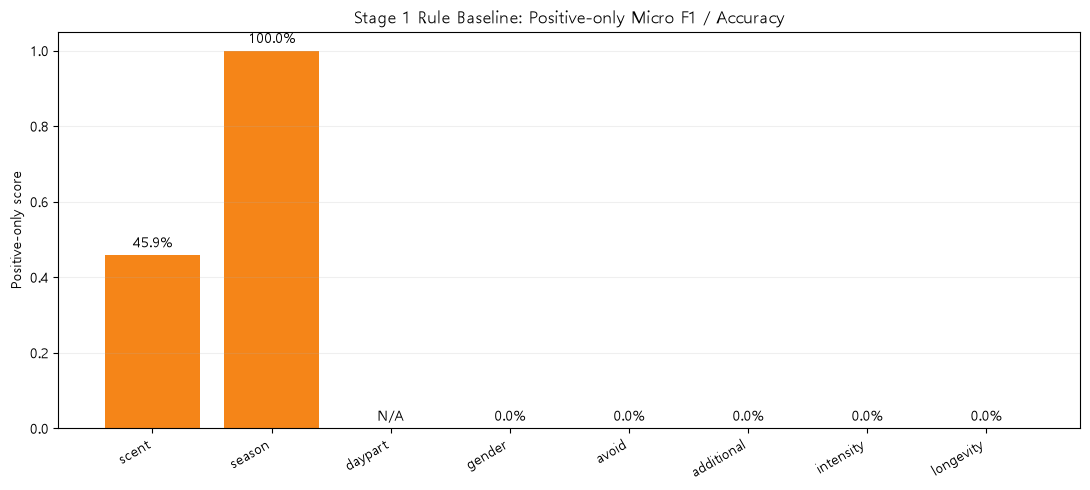

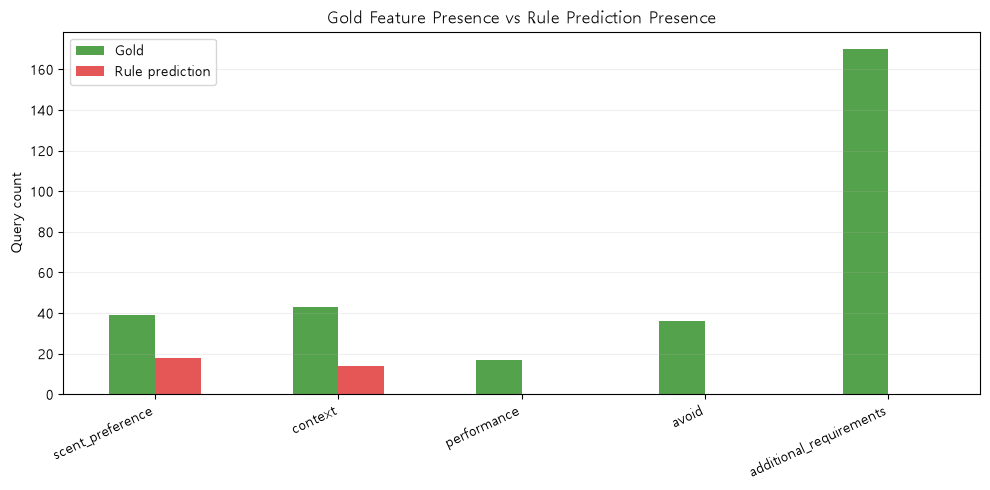

,Gold,Rule prediction
scent_preference,39,18
context,43,14
performance,17,0
avoid,36,0
additional_requirements,170,0


In [12]:
fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.bar(field_exact_rates.index, field_exact_rates.values, color="#4C78A8")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Exact Match Rate")
ax.set_title("Stage 1 Rule Baseline: Field-level Exact Match Rate")
ax.grid(axis="y", alpha=0.2)
for bar, value in zip(bars, field_exact_rates.values):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.02, f"{value:.1%}", ha="center")
plt.tight_layout()
plt.show()

plot_positive = positive_performance_df.copy()
fig, ax = plt.subplots(figsize=(11, 5))
plot_values = plot_positive["value"].fillna(0)
bars = ax.bar(plot_positive["field"], plot_values, color="#F58518")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Positive-only score")
ax.set_title("Stage 1 Rule Baseline: Positive-only Micro F1 / Accuracy")
ax.grid(axis="y", alpha=0.2)
for bar, value, eligible in zip(bars, plot_positive["value"], plot_positive["eligible_queries"]):
    label = "N/A" if pd.isna(value) or eligible == 0 else f"{value:.1%}"
    ax.text(bar.get_x() + bar.get_width()/2, (0 if pd.isna(value) else value) + 0.02, label, ha="center")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

pred_presence = pd.Series({
    "scent_preference": int(merged_df.pred_scent_preference.map(bool).sum()),
    "context": int(merged_df.pred_context.map(lambda x: any(map(bool, x.values()))).sum()),
    "performance": int(merged_df.pred_performance.map(lambda x: any(map(bool, x.values()))).sum()),
    "avoid": int(merged_df.pred_avoid.map(bool).sum()),
    "additional_requirements": int(merged_df.pred_additional_requirements.map(bool).sum()),
}, name="Rule prediction")
presence_df = pd.concat([gold_presence.rename("Gold"), pred_presence], axis=1)

ax = presence_df.plot(kind="bar", figsize=(10, 5), color=["#54A24B", "#E45756"])
ax.set_ylabel("Query count")
ax.set_title("Gold Feature Presence vs Rule Prediction Presence")
ax.grid(axis="y", alpha=0.2)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

display(presence_df)

## 13. Save Outputs

In [13]:
PREDICTIONS_PATH = OUTPUT_DIR / "13_rule_stage1_predictions.csv"
EVALUATION_PATH = OUTPUT_DIR / "13_rule_stage1_evaluation.csv"
ERRORS_PATH = OUTPUT_DIR / "13_rule_stage1_errors.csv"
METRICS_PATH = OUTPUT_DIR / "13_rule_stage1_metrics.csv"
SUMMARY_PATH = OUTPUT_DIR / "13_rule_stage1_summary.md"

prediction_output = predictions_df.drop(columns=["parser_error"]).copy()
for column in [
    "pred_scent_preference", "pred_context", "pred_performance",
    "pred_avoid", "pred_additional_requirements",
]:
    prediction_output[column] = prediction_output[column].map(json_text)

metric_rows = []


def add_metric(metric, value):
    if pd.isna(value):
        return
    metric_rows.append({"metric": metric, "value": float(value)})


add_metric("exact_match_count", exact_match_count)
add_metric("exact_match_rate", exact_match_rate)
add_metric("overall_exact_match", exact_match_rate)
for field, value in field_exact_rates.items():
    add_metric(f"{field}_exact_match", value)
for field, value in subfield_exact_rates.items():
    add_metric(f"{field.replace('.', '_')}_exact_match", value)

for field, values in all_multilabel_metrics.items():
    for metric in ["precision", "recall", "f1"]:
        add_metric(f"{field}_micro_{metric}", values[metric])
for field, values in scalar_metrics.items():
    add_metric(f"{field}_accuracy", values["accuracy"])

for field, values in positive_multilabel_metrics.items():
    add_metric(f"positive_{field}_eligible_count", values["eligible_queries"])
    if values["eligible_queries"]:
        for metric in ["precision", "recall", "f1"]:
            add_metric(f"positive_{field}_micro_{metric}", values[metric])
for field, values in positive_scalar_metrics.items():
    add_metric(f"positive_{field}_eligible_count", values["eligible_queries"])
    if values["eligible_queries"]:
        add_metric(f"positive_{field}_accuracy", values["accuracy"])

scent_prediction_coverage = float(merged_df.pred_scent_preference.map(bool).mean())
context_prediction_coverage = float(merged_df.pred_context.map(lambda x: any(map(bool, x.values()))).mean())
any_prediction_coverage = float(np.mean([
    bool(scent) or any(map(bool, context.values()))
    for scent, context in zip(merged_df.pred_scent_preference, merged_df.pred_context)
]))
add_metric("scent_prediction_coverage", scent_prediction_coverage)
add_metric("context_prediction_coverage", context_prediction_coverage)
add_metric("any_condition_prediction_coverage", any_prediction_coverage)
add_metric("parser_error_count", len(parser_errors_df))
for field, value in gold_presence.items():
    add_metric(f"gold_{field}_presence_count", value)
for field, value in pred_presence.items():
    add_metric(f"pred_{field}_presence_count", value)

metrics_df = pd.DataFrame(metric_rows)

top_components = pd.Series(component_counts).sort_values(ascending=False)
top_component_lines = "\n".join(
    f"- {name}: {int(count)}개" for name, count in top_components.head(8).items()
) or "- 오류 없음"

summary_text = f"""# Stage 1 Rule Baseline Evaluation

## 실험 목적

기존 11번 Rule Parser를 변경하지 않고, 실제 사용자 자연어 200개 Golden Set에서 Stage 1 Query Understanding 성능을 측정했다.

## 데이터

- Golden Set: 200 Queries
- Golden Set Version: stage1-v1.0
- 고유 query_id: {gold_df['query_id'].nunique()}개
- 고유 query_text: {gold_df['query_text'].nunique()}개

## Baseline

- 기존 11번 Rule Parser 및 고정된 11번 Rule Lexicon 사용
- 새로운 Rule, Lexicon, 동의어 매핑 추가 없음
- LLM, embedding, 외부 API, 향수 ranking 사용 없음

## 주요 결과

- 전체 Exact Match: {exact_match_count}/200 ({exact_match_rate:.2%})
- Parser 오류: {len(parser_errors_df)}개
- 하나 이상의 조건을 예측한 Coverage: {any_prediction_coverage:.2%}

## Field별 결과

- scent_preference Exact Match: {field_exact_rates['scent']:.2%}
- context Exact Match: {field_exact_rates['context']:.2%}
- performance Exact Match: {field_exact_rates['performance']:.2%}
- avoid Exact Match: {field_exact_rates['avoid']:.2%}
- additional_requirements Exact Match: {field_exact_rates['additional']:.2%}
- scent Positive-only Micro F1: {positive_multilabel_metrics['scent']['f1']:.2%} (Gold positive {positive_multilabel_metrics['scent']['eligible_queries']}개)

## 주요 실패 유형

{top_component_lines}

## 관찰

- 현재 Parser의 출력 구조는 scent, season, daypart를 지원하고 gender, performance, avoid, additional_requirements는 지원하지 않는다.
- 지원하지 않는 필드의 전체 Exact Match에는 Gold와 Prediction이 모두 빈 Query가 포함되므로, Positive-only 지표를 함께 해석해야 한다.
- Coverage는 값을 추출했는지만 나타내며, 추출한 값의 정답 여부는 Precision/Recall/F1 및 Exact Match로 별도 확인해야 한다.

## 결론

이 결과는 Golden Set을 보고 규칙을 보완하지 않은 고정 Baseline이다. 이후 확장 Rule Parser와 LLM Parser는 동일한 Golden Set, 동일한 normalization, 동일한 metric으로 비교해야 한다.
"""

prediction_output.to_csv(PREDICTIONS_PATH, index=False, encoding="utf-8-sig")
evaluation_df.to_csv(EVALUATION_PATH, index=False, encoding="utf-8-sig")
errors_df.to_csv(ERRORS_PATH, index=False, encoding="utf-8-sig")
metrics_df.to_csv(METRICS_PATH, index=False, encoding="utf-8-sig")
SUMMARY_PATH.write_text(summary_text, encoding="utf-8")

output_audit_df = pd.DataFrame([
    {"file": path.name, "rows": len(pd.read_csv(path)), "size_kb": path.stat().st_size / 1024}
    for path in [PREDICTIONS_PATH, EVALUATION_PATH, ERRORS_PATH, METRICS_PATH]
])
output_audit_df = pd.concat([
    output_audit_df,
    pd.DataFrame([{"file": SUMMARY_PATH.name, "rows": len(summary_text.splitlines()), "size_kb": SUMMARY_PATH.stat().st_size / 1024}]),
], ignore_index=True)
display(output_audit_df)

,file,rows,size_kb
0,13_rule_stage1_predictions.csv,200,35.6328
1,13_rule_stage1_evaluation.csv,200,79.4863
2,13_rule_stage1_errors.csv,197,78.5918
3,13_rule_stage1_metrics.csv,72,2.3799
4,13_rule_stage1_summary.md,54,1.8691


## 14. Final Summary

In [14]:
display(Markdown(summary_text))

assert len(gold_df) == 200
assert len(prediction_output) == 200
assert len(evaluation_df) == 200
assert len(errors_df) == 200 - exact_match_count
assert not evaluation_df.isna().any().any()
assert prediction_output.columns.tolist() == [
    "query_id", "query_text", "pred_scent_preference", "pred_context",
    "pred_performance", "pred_avoid", "pred_additional_requirements",
]
assert all(path.is_file() for path in [
    PREDICTIONS_PATH, EVALUATION_PATH, ERRORS_PATH, METRICS_PATH, SUMMARY_PATH,
])
print("최종 검증 완료: 200개 Query 처리, 필수 산출물 5개 생성, NaN/JSON parsing 오류 없음")

# Stage 1 Rule Baseline Evaluation

## 실험 목적

기존 11번 Rule Parser를 변경하지 않고, 실제 사용자 자연어 200개 Golden Set에서 Stage 1 Query Understanding 성능을 측정했다.

## 데이터

- Golden Set: 200 Queries
- Golden Set Version: stage1-v1.0
- 고유 query_id: 200개
- 고유 query_text: 200개

## Baseline

- 기존 11번 Rule Parser 및 고정된 11번 Rule Lexicon 사용
- 새로운 Rule, Lexicon, 동의어 매핑 추가 없음
- LLM, embedding, 외부 API, 향수 ranking 사용 없음

## 주요 결과

- 전체 Exact Match: 3/200 (1.50%)
- Parser 오류: 0개
- 하나 이상의 조건을 예측한 Coverage: 15.50%

## Field별 결과

- scent_preference Exact Match: 84.00%
- context Exact Match: 80.50%
- performance Exact Match: 91.50%
- avoid Exact Match: 82.00%
- additional_requirements Exact Match: 15.00%
- scent Positive-only Micro F1: 45.90% (Gold positive 39개)

## 주요 실패 유형

- MISSED_ADDITIONAL: 170개
- MISSED_GENDER: 36개
- MISSED_AVOID: 36개
- MISSED_SCENT: 25개
- MISSED_INTENSITY: 12개
- MISSED_LONGEVITY: 6개
- EXTRA_SCENT: 4개
- WRONG_SCENT: 3개

## 관찰

- 현재 Parser의 출력 구조는 scent, season, daypart를 지원하고 gender, performance, avoid, additional_requirements는 지원하지 않는다.
- 지원하지 않는 필드의 전체 Exact Match에는 Gold와 Prediction이 모두 빈 Query가 포함되므로, Positive-only 지표를 함께 해석해야 한다.
- Coverage는 값을 추출했는지만 나타내며, 추출한 값의 정답 여부는 Precision/Recall/F1 및 Exact Match로 별도 확인해야 한다.

## 결론

이 결과는 Golden Set을 보고 규칙을 보완하지 않은 고정 Baseline이다. 이후 확장 Rule Parser와 LLM Parser는 동일한 Golden Set, 동일한 normalization, 동일한 metric으로 비교해야 한다.


최종 검증 완료: 200개 Query 처리, 필수 산출물 5개 생성, NaN/JSON parsing 오류 없음


## 실행 결과 요약

- 전체 Query: **200개**
- 전체 Exact Match: **3/200 (1.50%)**
- Field Exact Match: **scent 84.00%, context 80.50%, performance 91.50%, avoid 82.00%, additional 15.00%**
- Positive-only scent Micro F1: **45.90%** (Gold positive 39개)
- 하나 이상의 조건을 예측한 Coverage: **15.50%**
- Exact Match 실패 Query: **197개**
- Parser 실행 오류: **0개**

생성 파일:

- `analysis_outputs/13_rule_stage1_predictions.csv`
- `analysis_outputs/13_rule_stage1_evaluation.csv`
- `analysis_outputs/13_rule_stage1_errors.csv`
- `analysis_outputs/13_rule_stage1_metrics.csv`
- `analysis_outputs/13_rule_stage1_summary.md`